# Espérance de vie et chocs : conflits, épidémies et catastrophes (2000–2021)

**Question :** *Peut-on prédire la baisse de l'espérance de vie d'un pays à partir des conflits armés, des épidémies et des catastrophes naturelles qu'il a subis ?*

Ce notebook réunit trois sources de données (ONU, UCDP, EM-DAT) dans un tableau « un pays, une année », puis entraîne des modèles d'apprentissage supervisé afin de repérer les années de choc et d'identifier le facteur le plus déterminant.

In [1]:
import pandas as pd
import numpy as np

## 1. Chargement et préparation des données démographiques

On charge les indicateurs démographiques de l'ONU et on ne conserve que les vrais pays (en écartant les agrégats régionaux), sur la période 2000–2021.

In [2]:
demographic = pd.read_csv("data/demographic.csv", low_memory=False)

In [3]:
# On garde uniquement les vrais pays (pas les régions ni "World")
pays = demographic[demographic['LocTypeName'] == 'Country/Area'].copy()

# On garde les colonnes utiles et on les renomme clairement
pays = pays[['ISO3_code', 'Location', 'Time', 'LEx']].rename(columns={
    'ISO3_code': 'iso3',
    'Location': 'pays',
    'Time': 'annee',
    'LEx': 'esperance_vie'
})

# On garde notre période d'étude
pays = pays[pays['annee'].between(2000, 2021)]

## 2. Construction de la variable à prédire (la cible)

On calcule la variation annuelle de l'espérance de vie de chaque pays. On définit une **baisse notable** (cible = 1) lorsqu'un pays perd plus d'une demi-année d'espérance de vie en un an : un seuil qui correspond à un vrai choc, l'espérance de vie augmentant normalement d'environ un quart d'année par an.

In [4]:
# On trie pour comparer chaque année à la précédente, pays par pays
pays = pays.sort_values(['pays', 'annee'])

# variation = espérance de vie de l'année − celle de l'année d'avant (même pays)
pays['variation'] = pays.groupby('pays')['esperance_vie'].diff()

# Cible : 1 si baisse notable (plus d'une demi-année perdue), sinon 0
pays['baisse_notable'] = (pays['variation'] < -0.5).astype(int)

In [5]:
pays['baisse_notable'].value_counts()

baisse_notable
0    4914
1     300
Name: count, dtype: int64

## 3. Préparation des conflits armés (UCDP)

On résume les conflits par pays et par année. On sépare d'abord les conflits touchant plusieurs pays, on harmonise les noms de pays avec les données démographiques, puis on calcule deux indicateurs : le nombre de conflits et la présence d'une guerre (intensité maximale).

In [6]:
conflits = pd.read_csv("data/conflicts.csv", low_memory=False)
conflits = conflits[conflits['year'].between(2000, 2021)].copy()

In [7]:
# "Egypt, Israel" sur une ligne -> on en fait 2 lignes (une par pays)
conflits['location'] = conflits['location'].astype(str).str.split(',')
conflits = conflits.explode('location')
conflits['location'] = conflits['location'].str.strip()

In [8]:
correction_noms = {
    'Cambodia (Kampuchea)': 'Cambodia',
    'DR Congo (Zaire)': 'Democratic Republic of the Congo',
    'Iran': 'Iran (Islamic Republic of)',
    'Ivory Coast': "Côte d'Ivoire",
    'Myanmar (Burma)': 'Myanmar',
    'Russia (Soviet Union)': 'Russian Federation',
    'Syria': 'Syrian Arab Republic',
    'Tanzania': 'United Republic of Tanzania',
    'Turkey': 'Türkiye',
    'Yemen (North Yemen)': 'Yemen',
}
conflits['location'] = conflits['location'].replace(correction_noms)

In [9]:
conflits_resume = conflits.groupby(['location', 'year']).agg(
    nb_conflits = ('conflict_id', 'nunique'),                         # combien de conflits cette année
    guerre      = ('intensity_level', lambda x: int((x == 2).any()))  # 1 si au moins une vraie guerre
).reset_index()

conflits_resume = conflits_resume.rename(columns={'location': 'pays', 'year': 'annee'})

In [10]:
conflits_resume[conflits_resume['pays'] == 'Syrian Arab Republic']

,pays,annee,nb_conflits,guerre
531,Syrian Arab Republic,2011,1,1
532,Syrian Arab Republic,2012,2,1
533,Syrian Arab Republic,2013,3,1
534,Syrian Arab Republic,2014,3,1
535,Syrian Arab Republic,2015,3,1
536,Syrian Arab Republic,2016,3,1
537,Syrian Arab Republic,2017,2,1
538,Syrian Arab Republic,2018,3,1
539,Syrian Arab Republic,2019,2,1
540,Syrian Arab Republic,2020,2,1


## 4. Préparation des catastrophes naturelles et des épidémies (EM-DAT)

On distingue les épidémies des autres catastrophes naturelles, puis on résume par pays et par année le nombre d'événements et le nombre de morts de chaque type.

In [11]:
catastrophes = pd.read_csv("data/disasters_1900_2021.csv", low_memory=False)
catastrophes = catastrophes[catastrophes['Year'].between(2000, 2021)].copy()

In [12]:
epidemies  = catastrophes[catastrophes['Disaster Type'] == 'Epidemic']
naturelles = catastrophes[catastrophes['Disaster Type'] != 'Epidemic']

In [13]:
epi_resume = epidemies.groupby(['ISO', 'Year']).agg(
    nb_epidemies    = ('Disaster Type', 'size'),   # combien d'épidémies
    morts_epidemies = ('Total Deaths', 'sum')      # morts dues aux épidémies
).reset_index()

nat_resume = naturelles.groupby(['ISO', 'Year']).agg(
    nb_catastrophes    = ('Disaster Type', 'size'),  # combien de catastrophes naturelles
    morts_catastrophes = ('Total Deaths', 'sum')     # morts dues aux catastrophes
).reset_index()

In [14]:
catastrophes_resume = pd.merge(nat_resume, epi_resume, on=['ISO', 'Year'], how='outer').fillna(0)
catastrophes_resume = catastrophes_resume.rename(columns={'ISO': 'iso3', 'Year': 'annee'})

In [15]:
catastrophes_resume[catastrophes_resume['iso3'] == 'HTI'].sort_values('annee')

,iso3,annee,nb_catastrophes,morts_catastrophes,nb_epidemies,morts_epidemies
1016,HTI,2000,2.0,16.0,0.0,0.0
1017,HTI,2001,2.0,26.0,0.0,0.0
1018,HTI,2002,2.0,35.0,0.0,0.0
1019,HTI,2003,5.0,88.0,1.0,40.0
1020,HTI,2004,3.0,5422.0,0.0,0.0
1021,HTI,2005,8.0,88.0,0.0,0.0
1022,HTI,2006,3.0,16.0,0.0,0.0
1023,HTI,2007,7.0,163.0,0.0,0.0
1024,HTI,2008,4.0,698.0,0.0,0.0
1025,HTI,2009,3.0,21.0,0.0,0.0


## 5. Fusion des trois sources

On réunit la cible, les conflits et les catastrophes dans un seul tableau « un pays, une année ». Les pays-années sans conflit ni catastrophe reçoivent la valeur 0 (absence d'événement, et non donnée manquante).

In [16]:
# On part de la table de base (cible) et on colle les conflits, puis les catastrophes
df = pays.merge(conflits_resume, on=['pays', 'annee'], how='left')
df = df.merge(catastrophes_resume, on=['iso3', 'annee'], how='left')

In [17]:
# Un pays-année sans conflit/catastrophe = 0 (et non "inconnu")
colonnes_chocs = ['nb_conflits', 'guerre', 'nb_catastrophes',
                  'morts_catastrophes', 'nb_epidemies', 'morts_epidemies']
df[colonnes_chocs] = df[colonnes_chocs].fillna(0)

# On retire la 1re année de chaque pays (variation vide)
df = df.dropna(subset=['variation'])

print("Tableau final :", df.shape)
df.head()

Tableau final : (4977, 12)


,iso3,pays,annee,esperance_vie,variation,baisse_notable,nb_conflits,guerre,nb_catastrophes,morts_catastrophes,nb_epidemies,morts_epidemies
1,AFG,Afghanistan,2001,55.5113,0.5066,0,2.0,1.0,4.0,331.0,2.0,154.0
2,AFG,Afghanistan,2002,56.2251,0.7138,0,1.0,0.0,8.0,1286.0,8.0,2797.0
3,AFG,Afghanistan,2003,57.1713,0.9462,0,1.0,0.0,9.0,137.0,0.0,0.0
4,AFG,Afghanistan,2004,57.8098,0.6385,0,1.0,0.0,3.0,18.0,0.0,0.0
5,AFG,Afghanistan,2005,58.2468,0.4370,0,1.0,1.0,13.0,582.0,1.0,0.0


## 6. Exploration visuelle

Deux graphiques pour comprendre les données : l'évolution de l'espérance de vie de pays marqués par des chocs, puis la variation moyenne selon la gravité (nombre de morts) des événements.

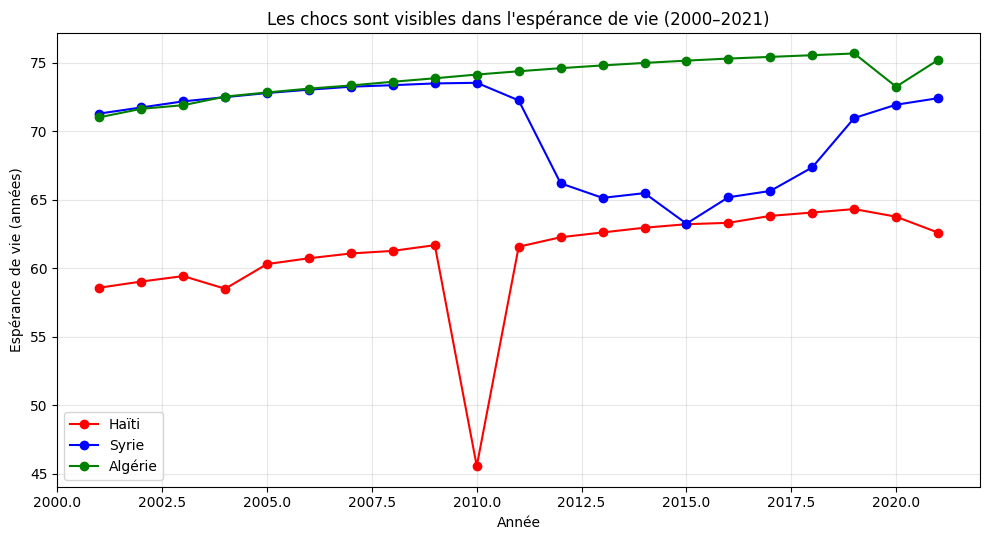

In [18]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5.5))
cibles = {'Haiti': 'red', 'Syrian Arab Republic': 'blue', 'Algeria': 'green'}
noms   = {'Haiti': 'Haïti', 'Syrian Arab Republic': 'Syrie', 'Algeria': 'Algérie'}

for p, couleur in cibles.items():
    sub = df[df['pays'] == p]
    ax.plot(sub['annee'], sub['esperance_vie'], marker='o', color=couleur, label=noms[p])

ax.set_title("Les chocs sont visibles dans l'espérance de vie (2000–2021)")
ax.set_xlabel("Année"); ax.set_ylabel("Espérance de vie (années)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

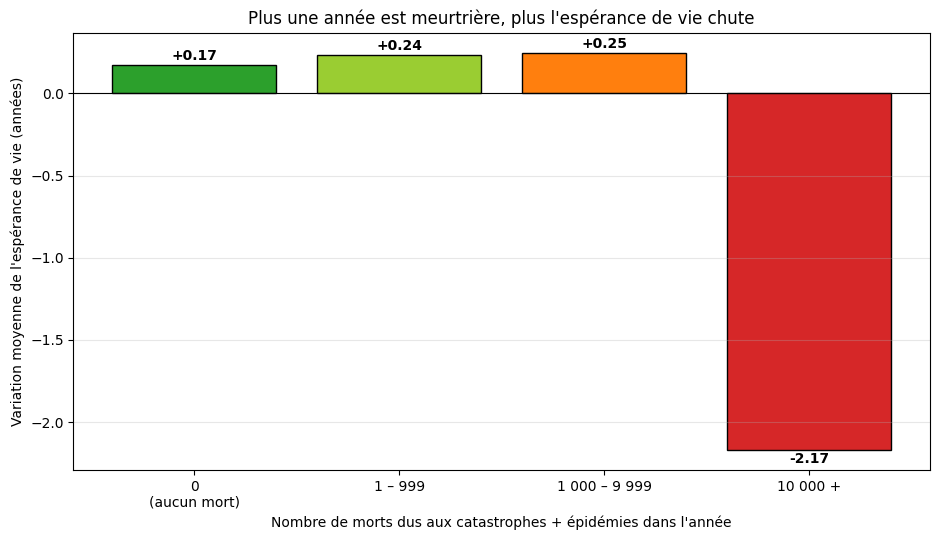

In [19]:
# Total de morts dus aux catastrophes + épidémies dans l'année
df['morts_chocs'] = df['morts_catastrophes'] + df['morts_epidemies']

# On range chaque année dans une tranche de gravité
def tranche_gravite(m):
    if m == 0:        return "0\n(aucun mort)"
    if m < 1000:      return "1 – 999"
    if m < 10000:     return "1 000 – 9 999"
    return "10 000 +"

df['gravite'] = df['morts_chocs'].apply(tranche_gravite)
ordre = ["0\n(aucun mort)", "1 – 999", "1 000 – 9 999", "10 000 +"]

# Variation moyenne de l'espérance de vie par tranche
moyennes = df.groupby('gravite')['variation'].mean().reindex(ordre)

fig, ax = plt.subplots(figsize=(9.5, 5.5))
couleurs = ['#2ca02c', '#9acd32', '#ff7f0e', '#d62728']
bars = ax.bar(ordre, moyennes.values, color=couleurs, edgecolor='black')

for b, v in zip(bars, moyennes.values):
    ax.text(b.get_x() + b.get_width()/2, v + (0.03 if v >= 0 else -0.08),
            f"{v:+.2f}", ha='center', fontweight='bold')

ax.axhline(0, color='black', lw=0.8)
ax.set_title("Plus une année est meurtrière, plus l'espérance de vie chute")
ax.set_ylabel("Variation moyenne de l'espérance de vie (années)")
ax.set_xlabel("Nombre de morts dus aux catastrophes + épidémies dans l'année")
ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

## 7. Apprentissage machine

On sépare les variables explicatives (les chocs) de la cible, puis on découpe les données en un jeu d'entraînement et un jeu de test. On entraîne deux modèles de classification : un arbre de décision (simple et interprétable) puis une forêt aléatoire (plus robuste).

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [21]:
indices = ['guerre', 'nb_conflits', 'nb_catastrophes',
           'morts_catastrophes', 'nb_epidemies', 'morts_epidemies']
X = df[indices]            # les indices
y = df['baisse_notable']   # la réponse à deviner

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Entraînement :", X_train.shape[0], "lignes | Test :", X_test.shape[0], "lignes")

Entraînement : 3981 lignes | Test : 996 lignes


In [24]:
arbre = DecisionTreeClassifier(max_depth=4, class_weight='balanced', random_state=42)
arbre.fit(X_train, y_train)                 # il apprend
pred_arbre = arbre.predict(X_test)          # il devine sur le test

print(classification_report(y_test, pred_arbre, target_names=['Normal', 'Choc']))

              precision    recall  f1-score   support

      Normal       0.95      0.59      0.72       936
        Choc       0.07      0.50      0.13        60

    accuracy                           0.58       996
   macro avg       0.51      0.54      0.43       996
weighted avg       0.90      0.58      0.69       996



In [25]:
foret = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
foret.fit(X_train, y_train)
pred_foret = foret.predict(X_test)

print(classification_report(y_test, pred_foret, target_names=['Normal', 'Choc']))
print("Matrice de confusion :\n", confusion_matrix(y_test, pred_foret))

              precision    recall  f1-score   support

      Normal       0.94      0.79      0.86       936
        Choc       0.07      0.23      0.10        60

    accuracy                           0.76       996
   macro avg       0.50      0.51      0.48       996
weighted avg       0.89      0.76      0.82       996

Matrice de confusion :
 [[742 194]
 [ 46  14]]


## 8. Résultats et évaluation des modèles

On classe d'abord les facteurs par importance, puis on mesure la qualité des modèles : exactitude, taux d'erreur, précision, rappel et F1-score sur la classe « choc ». On vérifie aussi l'absence de sur-apprentissage en comparant l'erreur d'apprentissage et l'erreur de test.

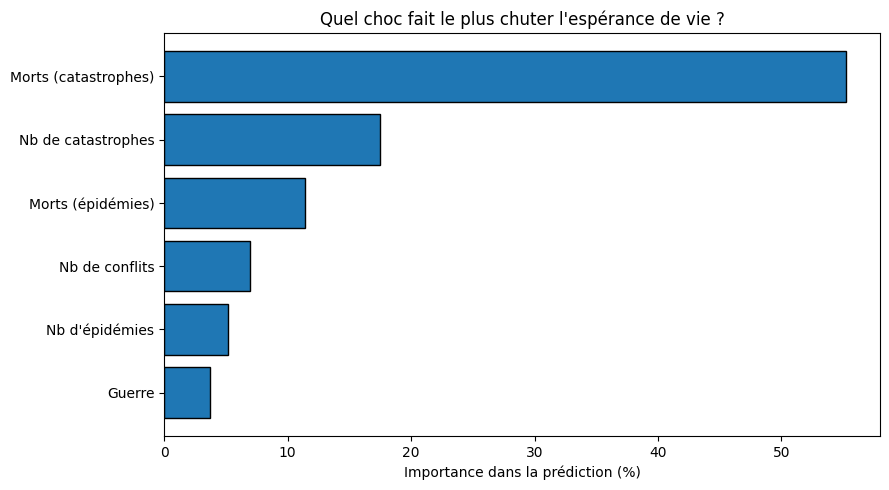

In [26]:
import matplotlib.pyplot as plt

importance = pd.Series(foret.feature_importances_, index=indices).sort_values()
labels = {'guerre':'Guerre', 'nb_conflits':'Nb de conflits', 'nb_catastrophes':'Nb de catastrophes',
          'morts_catastrophes':'Morts (catastrophes)', 'nb_epidemies':"Nb d'épidémies", 'morts_epidemies':'Morts (épidémies)'}

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh([labels[i] for i in importance.index], importance.values*100, color='#1f77b4', edgecolor='black')
ax.set_title("Quel choc fait le plus chuter l'espérance de vie ?")
ax.set_xlabel("Importance dans la prédiction (%)")
plt.tight_layout(); plt.show()

In [28]:
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix)

def rapport_modele(modele, nom):
    modele.fit(X_train, y_train)
    pred = modele.predict(X_test)
    acc = accuracy_score(y_test, pred)
    print(f"\n----- {nom} -----")
    print(f"  Exactitude        : {acc:.2f}")
    print(f"  Taux d'erreur     : {1-acc:.2f}")
    print(f"  Précision (choc)  : {precision_score(y_test, pred, zero_division=0):.2f}")
    print(f"  Rappel (choc)     : {recall_score(y_test, pred):.2f}")
    print(f"  F1-score (choc)   : {f1_score(y_test, pred):.2f}")
    print(f"  Train {modele.score(X_train, y_train):.2f} vs Test {acc:.2f}")
    print(f"  Matrice de confusion : {confusion_matrix(y_test, pred).tolist()}")

rapport_modele(arbre, "ARBRE DE DÉCISION")
rapport_modele(foret, "FORÊT ALÉATOIRE")


----- ARBRE DE DÉCISION -----
  Exactitude        : 0.58
  Taux d'erreur     : 0.42
  Précision (choc)  : 0.07
  Rappel (choc)     : 0.50
  F1-score (choc)   : 0.13
  Train 0.60 vs Test 0.58
  Matrice de confusion : [[549, 387], [30, 30]]

----- FORÊT ALÉATOIRE -----
  Exactitude        : 0.76
  Taux d'erreur     : 0.24
  Précision (choc)  : 0.07
  Rappel (choc)     : 0.23
  F1-score (choc)   : 0.10
  Train 0.81 vs Test 0.76
  Matrice de confusion : [[742, 194], [46, 14]]


## 9. Validation statistique (ANOVA)

On confirme statistiquement le lien entre la gravité des chocs et la baisse d'espérance de vie. L'ANOVA compare la variation moyenne entre les groupes de gravité : une p-value très faible signifie que les différences observées ne sont pas dues au hasard.

In [29]:
from scipy import stats

# On regroupe les années par gravité (nombre de morts dus aux chocs)
df['morts_chocs'] = df['morts_catastrophes'] + df['morts_epidemies']

g1 = df[df['morts_chocs'] == 0]['variation']
g2 = df[(df['morts_chocs'] > 0) & (df['morts_chocs'] < 1000)]['variation']
g3 = df[(df['morts_chocs'] >= 1000) & (df['morts_chocs'] < 10000)]['variation']
g4 = df[df['morts_chocs'] >= 10000]['variation']

F, p = stats.f_oneway(g1, g2, g3, g4)

print("Statistique F :", round(F, 2))
print("p-value       :", p)
print("Différence significative ?", "OUI" if p < 0.05 else "non")

Statistique F : 21.65
p-value       : 6.262907262303252e-14
Différence significative ? OUI


## Conclusion

Prédire l'année exacte d'un choc reste difficile : la plupart des baisses d'espérance de vie ont des causes situées en dehors des trois sources étudiées, et seuls les événements les plus meurtriers laissent une trace mesurable. L'analyse répond néanmoins clairement à la question de départ : c'est la **gravité des catastrophes** (le nombre de morts) qui est de loin le facteur le plus déterminant, devant les conflits et les épidémies. L'**ANOVA** confirme ce résultat de façon statistiquement significative (p ≈ 10⁻¹⁴).